In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [49]:
train = pd.read_csv('/content/fraudTrain.csv')

test = pd.read_csv('/content/fraudTest.csv')

In [50]:
train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [51]:
test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [52]:
train.shape

(1296675, 23)

In [53]:
test.shape

(555719, 23)

In [54]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [55]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [56]:
train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [57]:
test.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [58]:
train = train.dropna(subset=['is_fraud'])

test = test.dropna(subset=['is_fraud'])

In [59]:
train['is_fraud'].isnull().sum()

np.int64(0)

In [60]:
test['is_fraud'].isnull().sum()

np.int64(0)

In [61]:
test['is_fraud'].isnull().sum()

np.int64(0)

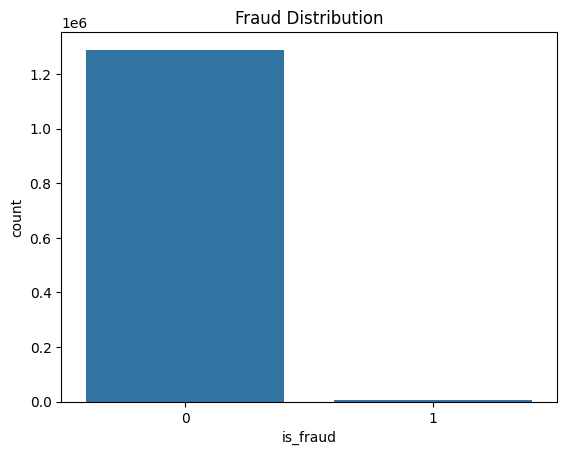

In [62]:
sns.countplot(x='is_fraud', data=train)

plt.title('Fraud Distribution')

plt.show()

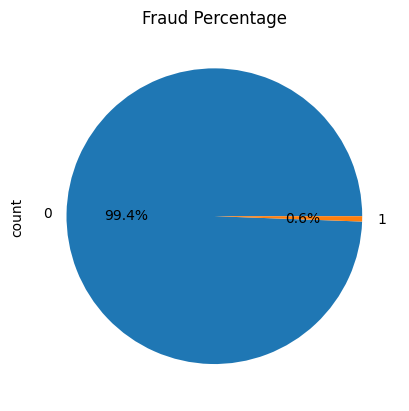

In [63]:
train['is_fraud'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Fraud Percentage')

plt.show()

In [64]:
data = pd.concat(
    [train, test],
    ignore_index=True
)

In [65]:
drop_cols = [

'Unnamed: 0',

'trans_date_trans_time',

'cc_num',

'first',

'last',

'street',

'city',

'state',

'zip',

'dob',

'trans_num'

]

data.drop(
    columns=drop_cols,
    inplace=True
)

In [66]:
data.columns

Index(['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop',
       'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [67]:
data.select_dtypes(
    include='object'
).columns

Index(['merchant', 'category', 'gender', 'job'], dtype='object')

In [68]:
encoder = LabelEncoder()

In [69]:
obj_cols = data.select_dtypes(
    include='object'
).columns

In [70]:
for col in obj_cols:

    data[col] = encoder.fit_transform(
        data[col].astype(str)
    )

In [71]:
data.isnull().sum()

,0
merchant,0
category,0
amt,0
gender,0
lat,0
long,0
city_pop,0
job,0
unix_time,0
merch_lat,0


In [72]:
data.isnull().sum().sum()

np.int64(0)

In [73]:
train_size = len(train)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

In [74]:
X_train = train_data.drop(
    'is_fraud',
    axis=1
)

y_train = train_data['is_fraud']

In [75]:
X_test = test_data.drop(
    'is_fraud',
    axis=1
)

y_test = test_data['is_fraud']

In [76]:
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train
)
X_test = scaler.transform(
    X_test
)

In [77]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)

In [78]:
accuracy_score(
    y_test,
    pred_lr
)

0.9955175187459849

In [79]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



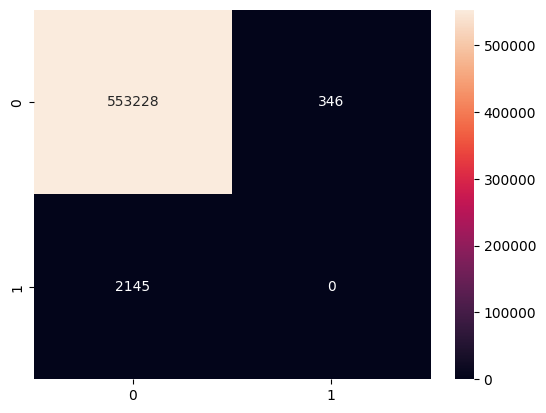

In [80]:
sns.heatmap(

confusion_matrix(
    y_test,
    pred_lr
),

annot=True,

fmt='d'

)

plt.show()

In [81]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(
    X_test
)

In [82]:
accuracy_score(
    y_test,
    pred_dt
)

0.9937018529148725

In [83]:
print(
    classification_report(
        y_test,
        pred_dt
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.32      0.57      0.41      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.78      0.70    555719
weighted avg       1.00      0.99      0.99    555719



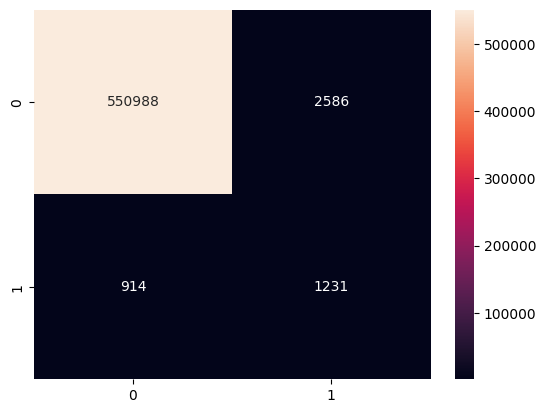

In [84]:
sns.heatmap(

confusion_matrix(
    y_test,
    pred_dt
),

annot=True,

fmt='d'

)

plt.show()

In [91]:
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(

X_train,

y_train

)

pred_rf = rf.predict(

X_test

)

In [92]:
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [93]:
accuracy_score(
    y_test,
    pred_rf
)

0.9971676332822883

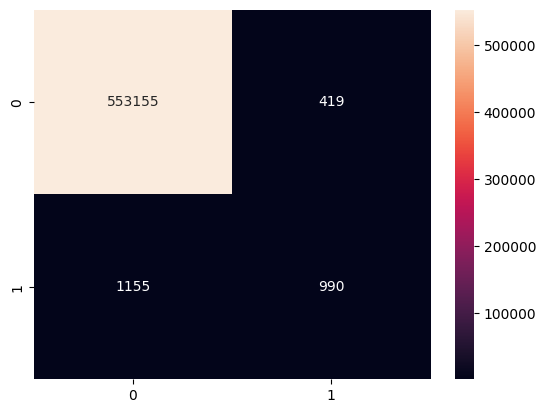

In [94]:
sns.heatmap(

confusion_matrix(
    y_test,
    pred_rf
),

annot=True,

fmt='d'

)

plt.show()

In [95]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.70      0.46      0.56      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.73      0.78    555719
weighted avg       1.00      1.00      1.00    555719



In [96]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.70      0.46      0.56      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.73      0.78    555719
weighted avg       1.00      1.00      1.00    555719



In [97]:
results = pd.DataFrame({

'Model': [

'Logistic Regression',

'Decision Tree',

'Random Forest'

],

'Accuracy': [

accuracy_score(
    y_test,
    pred_lr
),

accuracy_score(
    y_test,
    pred_dt
),

accuracy_score(
    y_test,
    pred_rf
)

]

})

results

,Model,Accuracy
0,Logistic Regression,0.995518
1,Decision Tree,0.993702
2,Random Forest,0.997168


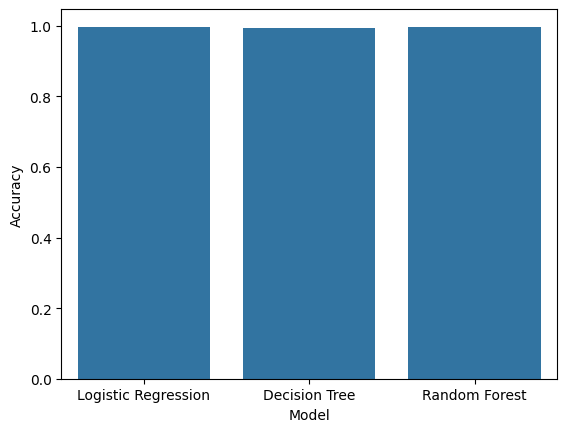

In [98]:
sns.barplot(

x='Model',

y='Accuracy',

data=results

)

plt.show()